<a href="https://colab.research.google.com/github/Sharif2138/African-Language-Health-QA-Challenge/blob/main/Exp4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment 4: mT5-small + LoRA — Proper Baseline

## What We Learned From Experiments 2 and 3

Experiments 2 and 3 both failed to produce coherent outputs. Investigation
revealed two compounding problems:

1. The decoder start token was misconfigured. In mT5's vocabulary,
   pad_token_id=0 is the correct decoder start token for seq2seq generation.
   eos_token_id=1 and extra_id_0 are both wrong choices.

2. 200 samples per language (1,600 total) is below the minimum threshold
   for mT5-small to learn the question-answer mapping. With only 100
   training steps per epoch, the model was repeating question tokens back
   as answers rather than generating anything meaningful.

## What Changes In Experiment 4

- Dataset: 500 samples per language (4,000 train, 1,200 val)
- decoder_start_token_id: 0 (pad_token, confirmed correct for mT5)
- Everything else identical to Exp 2/3

This is now the true generative baseline. All subsequent experiments
will change exactly one thing relative to this configuration so that
improvements can be attributed clearly.

## Hypothesis

With sufficient training data and the correct decoder start token,
training loss should drop normally and the model should generate
coherent multilingual health answers for the first time.

## Create Medium Dataset

500 samples per language for train, 150 per language for val.
This replaces the earlier 200/100 split which was too small.
Run this once — all experiments from here use these files.

In [ ]:
import pandas as pd
import numpy as np

train_full = pd.read_csv("/content/drive/MyDrive/datasets/train_clean.csv")
val_full   = pd.read_csv("/content/drive/MyDrive/datasets/val_clean.csv")
test       = pd.read_csv("/content/drive/MyDrive/datasets/test_clean.csv")

def make_small(df, n_per_lang, seed=42):
    parts = []
    for lang in df["subset"].unique():
        chunk = df[df["subset"] == lang]
        parts.append(
            chunk.sample(min(n_per_lang, len(chunk)), random_state=seed)
        )
    return pd.concat(parts).reset_index(drop=True)

train_small = make_small(train_full, 500)
val_small   = make_small(val_full,   150)

train_small.to_csv("/content/drive/MyDrive/datasets/train_small2.csv", index=False)
val_small.to_csv(  "/content/drive/MyDrive/datasets/val_small2.csv",   index=False)

print("train_small:", train_small.shape)
print("val_small  :", val_small.shape)
print()
print("train_small language distribution:")
print(train_small["subset"].value_counts())

train_small: (4000, 10)
val_small  : (1200, 4)

train_small language distribution:
subset
Aka_Gha    500
Amh_Eth    500
Eng_Eth    500
Eng_Gha    500
Eng_Ken    500
Eng_Uga    500
Lug_Uga    500
Swa_Ken    500
Name: count, dtype: int64


## Imports

In [ ]:
!pip install -q torchao==0.16.0
!pip install -q transformers datasets evaluate accelerate peft sentencepiece rouge-score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 53.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.4 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import transformers
from datasets import Dataset
import evaluate
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments
)
from peft import LoraConfig, TaskType, get_peft_model
from torch.utils.data import DataLoader

transformers.logging.set_verbosity_error()

## Load Data

In [ ]:
train_small = pd.read_csv("/content/drive/MyDrive/datasets/train_small2.csv")
val_small   = pd.read_csv("/content/drive/MyDrive/datasets/val_small2.csv")
test        = pd.read_csv("/content/drive/MyDrive/datasets/test_clean.csv")

train_ds = Dataset.from_pandas(train_small)
val_ds   = Dataset.from_pandas(val_small)
test_ds  = Dataset.from_pandas(test)

print("train_ds :", len(train_ds))
print("val_ds   :", len(val_ds))
print("test_ds  :", len(test_ds))

train_ds : 4000
val_ds   : 1200
test_ds  : 2618


## Tokenizer

We document the confirmed token IDs to avoid repeating the
decoder start token mistakes from Experiments 2 and 3.

In [ ]:
MODEL_NAME        = "google/mt5-small"
MAX_INPUT_LENGTH  = 96
MAX_TARGET_LENGTH = 192

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("pad_token  :", tokenizer.pad_token,  "| id:", tokenizer.pad_token_id)
print("eos_token  :", tokenizer.eos_token,  "| id:", tokenizer.eos_token_id)
print("unk_token  :", tokenizer.unk_token,  "| id:", tokenizer.unk_token_id)
print()
print("decoder_start_token_id will be set to:",
      tokenizer.pad_token_id, "->", tokenizer.pad_token)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/553 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/82.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

pad_token  : <pad> | id: 0
eos_token  : </s> | id: 1
unk_token  : <unk> | id: 2

decoder_start_token_id will be set to: 0 -> <pad>


## Tokenization

In [ ]:
def tokenize(examples):
    inputs = tokenizer(
        examples["input"],
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
        padding=False
    )
    targets = tokenizer(
        text_target=examples["output"],
        max_length=MAX_TARGET_LENGTH,
        truncation=True,
        padding=False
    )
    inputs["labels"] = [
        [t if t != tokenizer.pad_token_id else -100 for t in ids]
        for ids in targets["input_ids"]
    ]
    return inputs

def tokenize_test(examples):
    return tokenizer(
        examples["input"],
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
        padding=False
    )

tok_train = train_ds.map(tokenize,     batched=True, remove_columns=train_ds.column_names)
tok_val   = val_ds.map(tokenize,       batched=True, remove_columns=val_ds.column_names)
tok_test  = test_ds.map(tokenize_test, batched=True, remove_columns=test_ds.column_names)

print(tok_train)
print("sample labels (first 10):", tok_train[0]["labels"][:10])

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Map:   0%|          | 0/2618 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 4000
})
sample labels (first 10): [447, 135150, 481, 4445, 259, 272, 263, 4445, 282, 259]


## Model and LoRA

In [ ]:
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
model = model.float()

# Confirmed correct value for mT5 seq2seq generation
model.config.decoder_start_token_id = tokenizer.pad_token_id  # 0
model.config.forced_bos_token_id    = None

lora_cfg = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    r=4,
    lora_alpha=8,
    lora_dropout=0.1,
    target_modules=["q", "v"],
    bias="none"
)

model = get_peft_model(model, lora_cfg)
model.print_trainable_parameters()

pytorch_model.bin:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

trainable params: 172,032 || all params: 300,348,800 || trainable%: 0.0573


## Data Collator

In [ ]:
collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True,
    label_pad_token_id=-100,
    pad_to_multiple_of=8
)

## Evaluation Metric

In [ ]:
rouge = evaluate.load("rouge")

def compute_metrics(eval_preds):
    preds, labels = eval_preds
    preds  = np.clip(preds, 0, tokenizer.vocab_size - 1)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_preds  = tokenizer.batch_decode(preds,  skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    scores = rouge.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=True
    )
    return {
        "ROUGE1": round(scores["rouge1"], 4),
        "ROUGEL": round(scores["rougeL"], 4)
    }

## Training

In [ ]:
args = Seq2SeqTrainingArguments(
    output_dir="/content/drive/MyDrive/checkpoints/exp4",

    num_train_epochs=3,
    learning_rate=3e-4,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,

    weight_decay=0.01,
    max_grad_norm=1.0,

    fp16=False,
    bf16=False,

    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="ROUGE1",
    greater_is_better=True,

    generation_max_length=192,
    generation_num_beams=1,

    predict_with_generate=True,

    logging_strategy="steps",
    logging_steps=25,
    save_total_limit=1,
    dataloader_num_workers=0,
    report_to="none"
)

trainer = Seq2SeqTrainer(
    model=model,
    args=args,
    train_dataset=tok_train,
    eval_dataset=tok_val,
    data_collator=collator,
    compute_metrics=compute_metrics,
)

In [ ]:
trainer.train()

{'loss': '48.38', 'grad_norm': '732.5', 'learning_rate': '0.0002904', 'epoch': '0.1'}
{'loss': '47.43', 'grad_norm': '615.7', 'learning_rate': '0.0002804', 'epoch': '0.2'}
{'loss': '38.48', 'grad_norm': '215.4', 'learning_rate': '0.0002704', 'epoch': '0.3'}
{'loss': '29.43', 'grad_norm': '137.8', 'learning_rate': '0.0002604', 'epoch': '0.4'}
{'loss': '23.83', 'grad_norm': '66.24', 'learning_rate': '0.0002504', 'epoch': '0.5'}
{'loss': '20.96', 'grad_norm': '105.3', 'learning_rate': '0.0002404', 'epoch': '0.6'}
{'loss': '18.36', 'grad_norm': '44.27', 'learning_rate': '0.0002304', 'epoch': '0.7'}
{'loss': '16.95', 'grad_norm': '14.13', 'learning_rate': '0.0002204', 'epoch': '0.8'}
{'loss': '15.45', 'grad_norm': '6.015', 'learning_rate': '0.0002104', 'epoch': '0.9'}
{'loss': '14.77', 'grad_norm': '15.42', 'learning_rate': '0.0002004', 'epoch': '1'}
{'eval_loss': '5.563', 'eval_ROUGE1': '0.0395', 'eval_ROUGEL': '0.0363', 'eval_runtime': '614.2', 'eval_samples_per_second': '1.954', 'eval_st

TrainOutput(global_step=750, training_loss=17.34091483561198, metrics={'train_runtime': 2426.9324, 'train_samples_per_second': 4.945, 'train_steps_per_second': 0.309, 'train_loss': 17.34091483561198, 'epoch': 3.0})

## Save Best Model

In [ ]:
trainer.save_model("/content/drive/MyDrive/models/exp4/best_model")
tokenizer.save_pretrained("/content/drive/MyDrive/models/exp4/best_model")
print("Model saved")

Model saved


## Validation Predictions and Inspection

We use model.generate() directly to have full control over generation
parameters, particularly decoder_start_token_id.

In [ ]:
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

val_loader = DataLoader(
    tok_val,
    batch_size=8,
    collate_fn=DataCollatorForSeq2Seq(
        tokenizer=tokenizer,
        model=model,
        padding=True,
        pad_to_multiple_of=8
    )
)

pred_text = []
ref_text  = []

for batch in val_loader:
    input_ids      = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    labels         = batch["labels"]

    with torch.no_grad():
        outputs = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_new_tokens=192,
            num_beams=1,
            decoder_start_token_id=tokenizer.pad_token_id,
            forced_bos_token_id=None,
            no_repeat_ngram_size=3
        )

    pred_text.extend(
        tokenizer.batch_decode(outputs, skip_special_tokens=True)
    )

    labels = torch.where(labels != -100, labels, tokenizer.pad_token_id)
    ref_text.extend(
        tokenizer.batch_decode(labels, skip_special_tokens=True)
    )

print(f"Generated {len(pred_text)} predictions")

Generated 1200 predictions


In [ ]:
scores = rouge.compute(
    predictions=pred_text,
    references=ref_text,
    use_stemmer=True
)
print("ROUGE-1:", round(scores["rouge1"], 4))
print("ROUGE-L:", round(scores["rougeL"], 4))

ROUGE-1: 0.1597
ROUGE-L: 0.1069


In [ ]:
for i in range(5):
    print("="*70)
    print("LANGUAGE :", val_small.iloc[i]["subset"])
    print("QUESTION :", val_small.iloc[i]["input"][:150])
    print("REFERENCE:", ref_text[i][:200])
    print("GENERATED:", pred_text[i][:200])
    print()

LANGUAGE : Aka_Gha
QUESTION : So amammerɛ anaa nyamesom mu nsusuwii ahorow bi wɔ hɔ a, ebetumi aka sɛnea awofo anaa abusuafo yɛ wɔn ade wɔ mmabun nna ne awo akwahosan ho nsɛm ho?
REFERENCE: Yiw, amammerɛ ne nyamesom mu gyidi ahorow betumi anya sɛnea awofo anaa abusuafo yɛ wɔn ade wɔ mmabun nna ne awo akwahosan ho nsɛm ho no so nkɛntɛnso kɛse. Amammerɛ anaa ɔsom ahorow bi betumi asi ahobr
GENERATED: <extra_id_0> a nsɛm ho nnsɛnea ayɛ nsusuwii a wɔ nsu a, abɛma aa sɛma nɔ a. ae akɔ a naa ea wɔn a mu nɛ ao a ne a mɛ nmɛ e nyɛ a amɛ sɛnɛ bɛ nkɔ n’ n ntumi a mmɛ ɛm a; nkɛ o nkwɛ yɛ sɔm nsi a so a ma 

LANGUAGE : Aka_Gha
QUESTION : Dwuma bɛn na ahyehyɛde ahorow a egyina mpɔtamu hɔ, nhyehyɛe ahorow a mmabun di anim, ne atipɛnfo nkitahodi betumi adi wɔ mmabun nna ne awoɔ apomoden a
REFERENCE: Ahyehyɛde ahorow a egyina mpɔtamu hɔ, nhyehyɛe ahorow a mmabun di anim, ne atipɛnfo nkitahodi di dwuma titiriw wɔ mmabun nna ne awoɔ apomoden a wɔboa wɔ wiase nyinaa apomoden ho tebea horow a egye ntɛ
GEN

## Learning Curves

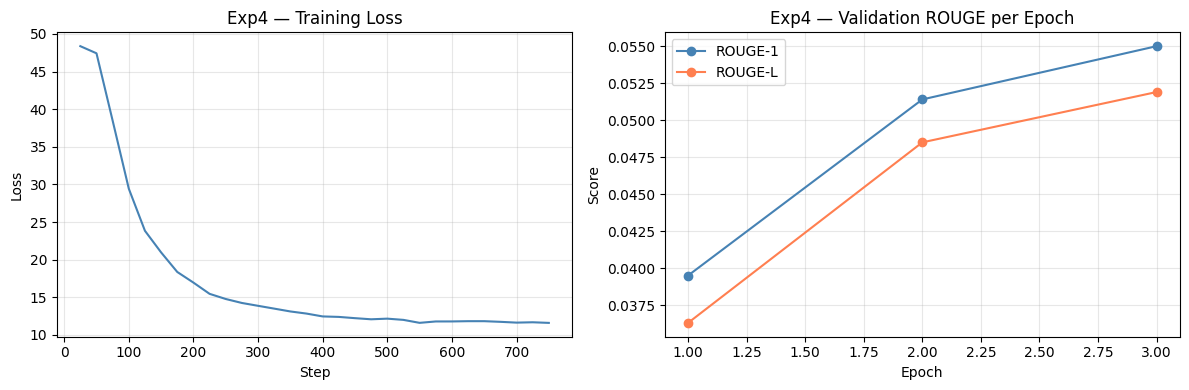

Plot saved


In [ ]:
history    = pd.DataFrame(trainer.state.log_history)
train_logs = history.dropna(subset=["loss"])
eval_logs  = history.dropna(subset=["eval_ROUGE1"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_logs["step"], train_logs["loss"], color="steelblue")
axes[0].set_title("Exp4 — Training Loss")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)

axes[1].plot(eval_logs["epoch"], eval_logs["eval_ROUGE1"],
             marker="o", label="ROUGE-1", color="steelblue")
axes[1].plot(eval_logs["epoch"], eval_logs["eval_ROUGEL"],
             marker="o", label="ROUGE-L", color="coral")
axes[1].set_title("Exp4 — Validation ROUGE per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/plots/exp4_curves.png",
    dpi=300, bbox_inches="tight"
)
plt.show()
print("Plot saved")

In [ ]:
# Check English examples specifically
eng_indices = val_small[val_small["subset"].str.startswith("Eng")].index[:3].tolist()

for i in eng_indices:
    print("="*70)
    print("LANGUAGE :", val_small.iloc[i]["subset"])
    print("QUESTION :", val_small.iloc[i]["input"][:150])
    print("REFERENCE:", ref_text[i][:200])
    print("GENERATED:", pred_text[i][:200])
    print()

LANGUAGE : Eng_Eth
QUESTION : Is it true that a blood test is enough for all STIs?
REFERENCE: No. Some STIs need urine tests or swabs. Blood tests check HIV and syphilis.
GENERATED: <extra_id_0> is enough for all STIs. It is true that a blood test is sufficient for all infections. The infection is a very limited. It does not a good a test for all the infection. It has a symptoms 

LANGUAGE : Eng_Eth
QUESTION : What is the importance of water purification (boiling and filtering) in reducing disease?
REFERENCE: Boiling and filtering kill the invisible germs that cause diarrhea, cholera, and typhoid, which are the leading killers of young children.
GENERATED: <extra_id_0> and prevention of diseases. The importance of water therapy. The important importance for prevention and treatment of infections. The need of water treatment and infection. The use of wat

LANGUAGE : Eng_Eth
QUESTION : Can men carry trichomoniasis without knowing, and how can it be prevented?
REFERENCE: Yes, men often ca

In [ ]:
def clean(text):
    # remove extra_id sentinel tokens that appear at generation start
    import re
    text = re.sub(r"<extra_id_\d+>", "", text).strip()
    return text

pred_text_clean = [clean(p) for p in pred_text]

# Recompute ROUGE on cleaned predictions
scores = rouge.compute(
    predictions=pred_text_clean,
    references=ref_text,
    use_stemmer=True
)
print("ROUGE-1 (cleaned):", round(scores["rouge1"], 4))
print("ROUGE-L (cleaned):", round(scores["rougeL"], 4))

ROUGE-1 (cleaned): 0.1638
ROUGE-L (cleaned): 0.11
